# Hex Maze Spyglass Process!
---

You can skip down a couple cells to the "fast version" that has everything in one cell. But if you're still working through things, I have it split up by cell up here.

(Note this "full process" doesn't include ephys + sorting + decoding, because those are covered in separate tutorials)

## 1: Insert the session into spyglass

In [ ]:
import spyglass.common as sgc
import spyglass.position as sgp
import spyglass.data_import as sgi
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass_hexmaze.hex_maze_behavior import (
    populate_all_hexmaze,
    populate_hex_position,
)
from spyglass_hexmaze.berke_fiber_photometry import populate_all_fiber_photometry

# File name of an nwb in /stelmo/nwb/raw
# Berke lab nwbs actually live in /squall-b/nwbs, and are symlinked to stelmo
nwb_file_name = "IM-1478_20220719.nwb"

# When we run insert_session, spyglass creates a copy of the nwbfile named file name + _
# We use nwb_copy_file_name to make it explicit which one to use.
# Everything besides sgi.insert_session should use the copy file name
nwb_copy_file_name = get_nwb_copy_filename(nwb_file_name)

## Step 1.
# Insert session into spyglass (populates all common tables)
sgi.insert_sessions(nwb_file_name)

#### Confirm it worked!

In [3]:
from spyglass.common import Session, TaskEpoch

## Step 1 check: Confirm the nwbfile has been added to the Session and TaskEpoch tables
key = {"nwb_file_name": nwb_copy_file_name}

display(Session() & key)
display(TaskEpoch() & key)

nwb_file_name name of the NWB file,subject_id,institution_name,lab_name,session_id,session_description,session_start_time,timestamps_reference_time,experiment_description
IM-1478_20220719_.nwb,IM-1478,"University of California, San Francisco",Berke Lab,IM-1478_20220719,barrier change session for the hex maze task with 3 blocks and 185 trials.,2022-07-19 13:07:06,2022-07-19 13:07:06,Hex maze task


nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),task_name,camera_name,interval_list_name descriptive name of this interval list,task_environment the environment the animal was in,camera_names list of keys corresponding to entry in CameraDevice
IM-1478_20220719_.nwb,0,Hex maze,None,00_r1,hexmaze,=BLOB=


## 2: Insert into hex maze tables

In [80]:
## Step 2.
# Once the session has been inserted, insert into basic hex maze tables
# populates HexMazeBlock, HexMazeBlock.Trial, HexMazeChoice, HexMazeTrialHistory, HexCentroids, HexMazeConfig
populate_all_hexmaze(nwb_copy_file_name)

#### Confirm it worked!

In [4]:
from spyglass_hexmaze.hex_maze_behavior import (
    HexMazeBlock,
    HexCentroids,
    HexMazeConfig,
    HexMazeChoice,
    HexMazeTrialHistory,
)

## Step 2 check: Confirm the nwbfile has been added to the basic hex maze tables
key = {"nwb_file_name": nwb_copy_file_name}

# Show the HexMazeBlock table
print("HexMazeBlock table:")
display(HexMazeBlock() & key)

# Show the Trial part table
print("HexMazeBlock().Trial part table:")
display(HexMazeBlock().Trial() & key)

# Show the HexMazeChoice table
print("HexMazeChoice table:")
display(HexMazeChoice() & key)

# Show the HexMazeTrialHistory table
print("HexMazeTrialHistory table:")
display(HexMazeTrialHistory() & key)

# Show the HexCentroids table (nwb_file_name is key)
print("HexCentroids table:")
display(HexCentroids() & key)

# Show the HexCentroids part table (nwb_file_name and hex)
print("HexCentroidsPart:")
display((HexCentroids().HexCentroidsPart()) & key)

# All config_ids for blocks in your session will also now exist in the HexMazeConfig table
# Show the HexMazeConfig table
print("HexMazeConfig table (not restricted by nwb_file_name, includes all sessions):")
display(HexMazeConfig())

HexMazeBlock table:


nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),block the block number within the epoch,config_id maze configuration as a string,interval_list_name descriptive name of this interval list,p_a probability of reward at port A,p_b probability of reward at port B,p_c probability of reward at port C,num_trials number of trials in this block,task_type 'barrier shift' or 'probabilty shift'
IM-1478_20220719_.nwb,0,1,"8,9,16,18,23,27,35,42,44",epoch0_block1,90.0,10.0,50.0,65,barrier change
IM-1478_20220719_.nwb,0,2,"8,9,18,21,23,27,35,42,44",epoch0_block2,90.0,10.0,50.0,62,barrier change
IM-1478_20220719_.nwb,0,3,"8,9,18,21,23,24,27,42,44",epoch0_block3,90.0,10.0,50.0,58,barrier change


HexMazeBlock().Trial part table:


nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),block the block number within the epoch,block_trial_num trial number within the block,interval_list_name descriptive name of this interval list,epoch_trial_num trial number within the epoch,reward if the rat got a reward,"start_port A, B, or C","end_port A, B, or C","opto_cond description of opto condition, if any (delay / no_delay)","poke_interval np.array of [poke_in, poke_out]",duration trial duration in seconds
IM-1478_20220719_.nwb,0,1,1,epoch0_block1_trial1,1,0,None,C,None,=BLOB=,10.5167
IM-1478_20220719_.nwb,0,1,2,epoch0_block1_trial2,2,1,C,B,None,=BLOB=,31.1152
IM-1478_20220719_.nwb,0,1,3,epoch0_block1_trial3,3,1,B,C,None,=BLOB=,21.6368
IM-1478_20220719_.nwb,0,1,4,epoch0_block1_trial4,4,1,C,A,None,=BLOB=,54.662
IM-1478_20220719_.nwb,0,1,5,epoch0_block1_trial5,5,0,A,B,None,=BLOB=,9.01763
IM-1478_20220719_.nwb,0,1,6,epoch0_block1_trial6,6,0,B,C,None,=BLOB=,17.0026
IM-1478_20220719_.nwb,0,1,7,epoch0_block1_trial7,7,1,C,A,None,=BLOB=,81.1043
IM-1478_20220719_.nwb,0,1,8,epoch0_block1_trial8,8,0,A,B,None,=BLOB=,22.7089
IM-1478_20220719_.nwb,0,1,9,epoch0_block1_trial9,9,1,B,C,None,=BLOB=,32.461
IM-1478_20220719_.nwb,0,1,10,epoch0_block1_trial10,10,1,C,A,None,=BLOB=,18.5386


HexMazeChoice table:


...

nwb_file_name name of the NWB file
IM-1478_20220719_.nwb


HexCentroidsPart:


nwb_file_name name of the NWB file,hex the hex ID in the hex maze (1-49),"x_pixels the x coordinate of the hex centroid, in video pixel coordinates","y_pixels the y coordinate of the hex centroid, in video pixel coordinates","x_cm the x coordinate of the hex centroid, in cm","y_cm the y coordinate of the hex centroid, in cm"
IM-1478_20220719_.nwb,1,326.0,56.0,103.822,17.8344
IM-1478_20220719_.nwb,10,326.0,172.0,103.822,54.7771
IM-1478_20220719_.nwb,11,259.0,169.0,82.4841,53.8217
IM-1478_20220719_.nwb,12,394.0,206.0,125.478,65.6051
IM-1478_20220719_.nwb,13,324.0,210.0,103.185,66.879
IM-1478_20220719_.nwb,14,258.0,209.0,82.1656,66.5605
IM-1478_20220719_.nwb,15,425.0,230.0,135.35,73.2484
IM-1478_20220719_.nwb,16,361.0,227.0,114.968,72.293
IM-1478_20220719_.nwb,17,293.0,228.0,93.3121,72.6115
IM-1478_20220719_.nwb,18,230.0,224.0,73.2484,71.3376


HexMazeConfig table (not restricted by nwb_file_name, includes all sessions):


config_id maze configuration as a string,len_ab number of hexes on optimal path between ports A and B,len_bc number of hexes on optimal path between ports B and C,len_ac number of hexes on optimal path between ports A and C,"path_length_diff max path length difference between lenAB, lenBC, lenAC",num_choice_points number of critical choice points for this maze config,num_cycles number of graph cycles (closed loops) for this maze config,choice_points list of hexes that are choice points (not query-able),num_dead_ends number of dead ends at least 3 hexes long,optimal_pct percentage of maze hexes that are on optimal paths,non_optimal_pct percentage of maze hexes that are on non-optimal paths,dead_end_pct percentage of maze hexes that are on dead-end paths
"10,11,13,14,15,25,30,34,37,44,46",23,21,15,8,1,0,=BLOB=,0,76.32,0.0,23.68
"10,11,13,19,22,25,30,39,42",21,17,15,6,1,0,=BLOB=,1,65.0,0.0,35.0
"10,11,14,15,19,21,25,34,37,41,46",21,17,17,4,1,0,=BLOB=,1,71.05,0.0,28.95
"10,11,14,15,20,26,28,31,38,40",19,15,19,4,1,0,=BLOB=,2,66.67,0.0,33.33
"10,11,14,15,21,25,34,37,41,44,46",21,19,15,6,1,0,=BLOB=,0,71.05,0.0,28.95
"10,11,14,15,25,30,34,37,41,44,46",17,19,15,4,1,0,=BLOB=,1,65.79,0.0,34.21
"10,11,14,17,20,23,25,34,37,41,45",21,17,17,4,1,0,=BLOB=,1,71.05,0.0,28.95
"10,11,14,19,20,23,25,27,34,37,45",19,15,21,6,1,0,=BLOB=,0,71.05,0.0,28.95
"10,11,14,19,20,23,25,34,37,41,45",17,17,21,4,1,0,=BLOB=,1,71.05,0.0,28.95
"10,11,14,19,20,26,28,31,38,40",19,15,19,4,1,0,=BLOB=,2,66.67,0.0,33.33


## 3: Process position

NOTE I have set up some sets of parameters which may or may not be what you want!!!!

`"berke_double_led"` is the same as `"default"` but with the LED order switched (unlike Frank lab, we want `led1_is_front: 0`).

`"berke_double_led_500"` is the same as above, but upsampled to 500 Hz for decoding.

Check out the [spyglass position tutorial](https://github.com/LorenFrankLab/spyglass/blob/master/notebooks/20_Position_Trodes.ipynb) for more info.

If you only track one point with DLC instead of 2, you should probably be using `single_led` parameters. But look into it!

In [5]:
## Step 3.
# Process position using some parameters
# We only have one epoch (epoch 0) for Berke lab, so "pos 0 valid times" is always the interval list name
interval_list_name = "pos 0 valid times"

# Our position selection key includes the nwbfile name, the interval to process, and the parameters to use
position_selection_key = {
    "nwb_file_name": nwb_copy_file_name,
    "interval_list_name": interval_list_name,
    "trodes_pos_params_name": "berke_double_led",  # YOU MAY WANT / NEED TO CHANGE THIS
}
# To associate a set of parameters with a given interval, insert them into the `TrodesPosSelection` table
# Note "trodes position" really just means any imported unprocessed position
sgp.v1.TrodesPosSelection.insert1(position_selection_key, skip_duplicates=True)

# We can run the pipeline for our chosen interval/parameters by using the `TrodesPosV1.populate`
# Each NWB file, interval, and parameter set is now associated with a new analysis file and object ID.
sgp.v1.TrodesPosV1.populate(position_selection_key)

{'success_count': 0, 'error_list': []}

#### Confirm it worked!

In [6]:
from spyglass.position import PositionOutput

## Step 3 check: Confirm the nwbfile has been added to the PositionOutput table
key = {"nwb_file_name": nwb_copy_file_name}

# PositionOutput is a merge table with only merge_id as primary key, so we restrict by merge_get_part instead of & key
print("PositionOutput table restricted by merge_get_part(restriction=key)")
display(PositionOutput.merge_get_part(restriction=key))

# The above is equivalent to referencing the part table directly and doing & key
print(
    "PositionOutput.TrodesPosV1() part table restricted by key (should be same as above!!)"
)
display(PositionOutput().TrodesPosV1() & key)

# We can also use merge_view! This also gives us 'source'. Note that it is TrodesPosV1, the part table!
print("PositionOutput merge_view")
display(PositionOutput.merge_view(restriction=f"nwb_file_name='{nwb_copy_file_name}'"))

PositionOutput table restricted by merge_get_part(restriction=key)


merge_id,nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list,trodes_pos_params_name name for this set of parameters
11c287c0-639b-c56d-afba-7b7ab21ea051,IM-1478_20220719_.nwb,pos 0 valid times,berke_double_led
7cb970d3-e391-38fd-26ce-549bba694329,IM-1478_20220719_.nwb,pos 0 valid times,berke_double_led_500


PositionOutput.TrodesPosV1() part table restricted by key (should be same as above!!)


merge_id,nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list,trodes_pos_params_name name for this set of parameters
11c287c0-639b-c56d-afba-7b7ab21ea051,IM-1478_20220719_.nwb,pos 0 valid times,berke_double_led
7cb970d3-e391-38fd-26ce-549bba694329,IM-1478_20220719_.nwb,pos 0 valid times,berke_double_led_500


PositionOutput merge_view
*merge_id      *source        *nwb_file_name *interval_list *trodes_pos_pa
+------------+ +------------+ +------------+ +------------+ +------------+
11c287c0-639b- TrodesPosV1    IM-1478_202207 pos 0 valid ti berke_double_l
7cb970d3-e391- TrodesPosV1    IM-1478_202207 pos 0 valid ti berke_double_l
 (Total: 2)



None

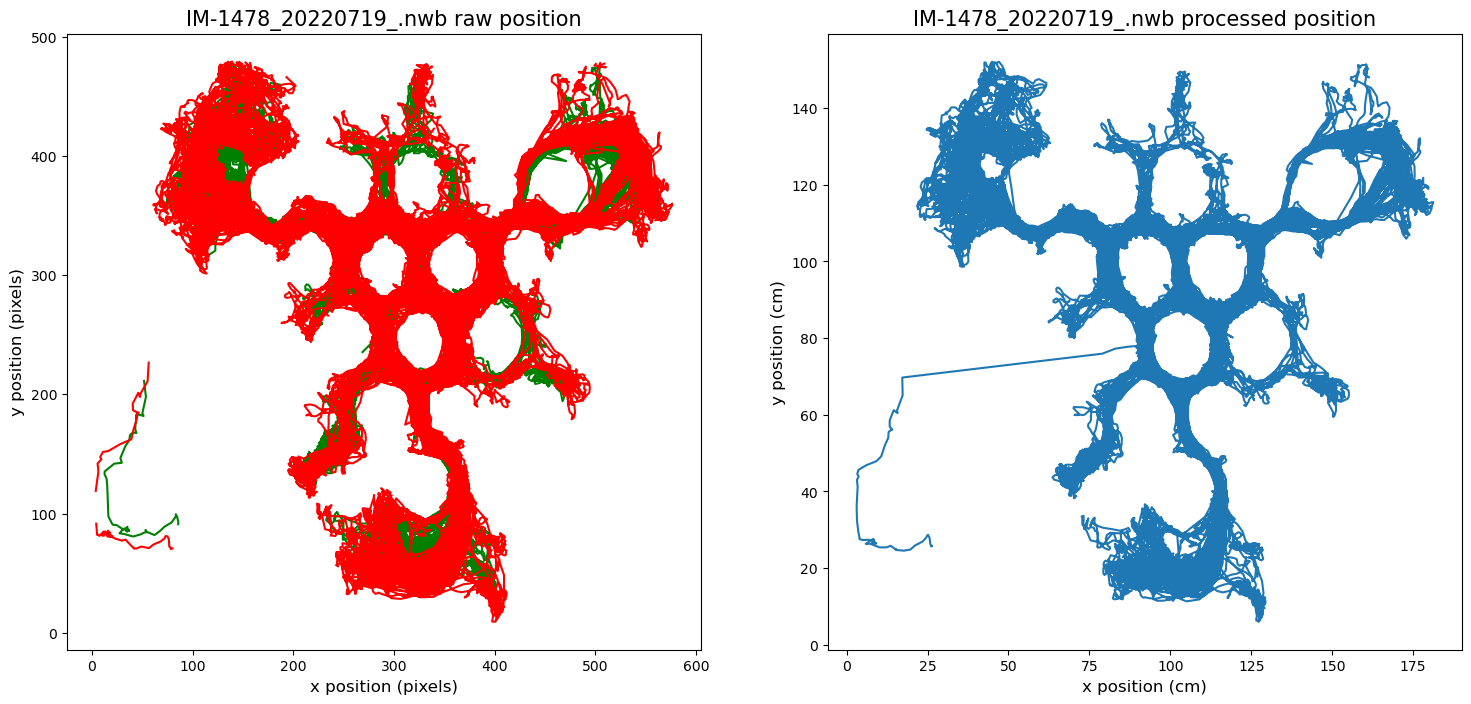

In [7]:
import matplotlib.pyplot as plt

# Plot raw position
raw_position_key = {"nwb_file_name": nwb_copy_file_name, "interval_list_name": interval_list_name}
raw_position_df = (sgc.RawPosition() & raw_position_key).fetch1_dataframe()

fig, ax = plt.subplots(1, 2, figsize=(18, 8))
ax[0].plot(raw_position_df.xloc1, raw_position_df.yloc1, color="green")
ax[0].plot(raw_position_df.xloc2, raw_position_df.yloc2, color="red")
ax[0].set_xlabel("x position (pixels)", fontsize=12)
ax[0].set_ylabel("y position (pixels)", fontsize=12)
ax[0].set_title(f"{nwb_copy_file_name} raw position", fontsize=15)

# Plot processed position
processed_position_merge_key = (PositionOutput.merge_get_part(key)).fetch("KEY")[0]
processed_position_df = (PositionOutput & processed_position_merge_key).fetch1_dataframe()

ax[1].plot(processed_position_df.position_x, processed_position_df.position_y)
ax[1].set_xlabel("x position (cm)", fontsize=12)
ax[1].set_ylabel("y position (cm)", fontsize=12)
ax[1].set_title(f"{nwb_copy_file_name} processed position", fontsize=15)
plt.show()

## 4. Assign position to hex

In [10]:
## Step 4.
# Insert into HexPositionSelection, HexPosition, and HexPath tables
# (must have run populate_all_hexmaze (Step 2) and have an entry in the PositionOutput table (Step 3))
populate_hex_position(nwb_copy_file_name)

[2026-03-25 19:10:33,099][WARNING]: Reconnecting to MySQL server.


Inserted new key {'nwb_file_name': 'IM-1478_20220719_.nwb', 'epoch': 0, 'pos_merge_id': UUID('7cb970d3-e391-38fd-26ce-549bba694329')} into HexPositionSelection
Populating HexPosition for 2 entries in IM-1478_20220719_.nwb


[19:10:50][WARNING] Spyglass: Upsampled position data, frame indices are invalid. Setting add_frame_ind=False
[19:11:25][INFO] Spyglass: Writing new NWB file IM-1478_20220719_IGMIWJUUKH.nwb
INFO:spyglass:Writing new NWB file IM-1478_20220719_IGMIWJUUKH.nwb
[19:12:54][INFO] Spyglass: Writing new NWB file IM-1478_20220719_TCBHRN4470.nwb
INFO:spyglass:Writing new NWB file IM-1478_20220719_TCBHRN4470.nwb


#### Confirm it worked!

HexPositionSelection table:


pos_merge_id,nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based)
11c287c0-639b-c56d-afba-7b7ab21ea051,IM-1478_20220719_.nwb,0
7cb970d3-e391-38fd-26ce-549bba694329,IM-1478_20220719_.nwb,0


HexPosition table:


pos_merge_id,nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),analysis_file_name name of the file,hex_assignment_object_id
11c287c0-639b-c56d-afba-7b7ab21ea051,IM-1478_20220719_.nwb,0,IM-1478_20220719_5USN1OO2UX.nwb,e49c1344-c636-4655-b569-8666380d816b
7cb970d3-e391-38fd-26ce-549bba694329,IM-1478_20220719_.nwb,0,IM-1478_20220719_IGMIWJUUKH.nwb,748a7285-3cda-48eb-8db9-3192bf40a253


HexPath table:


pos_merge_id,nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),analysis_file_name name of the file,hex_path_object_id
11c287c0-639b-c56d-afba-7b7ab21ea051,IM-1478_20220719_.nwb,0,IM-1478_20220719_Q1FJAJS3ND.nwb,d3ef3ea9-e542-4633-8739-2b5eab0dd3c2
7cb970d3-e391-38fd-26ce-549bba694329,IM-1478_20220719_.nwb,0,IM-1478_20220719_TCBHRN4470.nwb,51fb8ffd-40bf-40cc-97ef-638ee67903d6


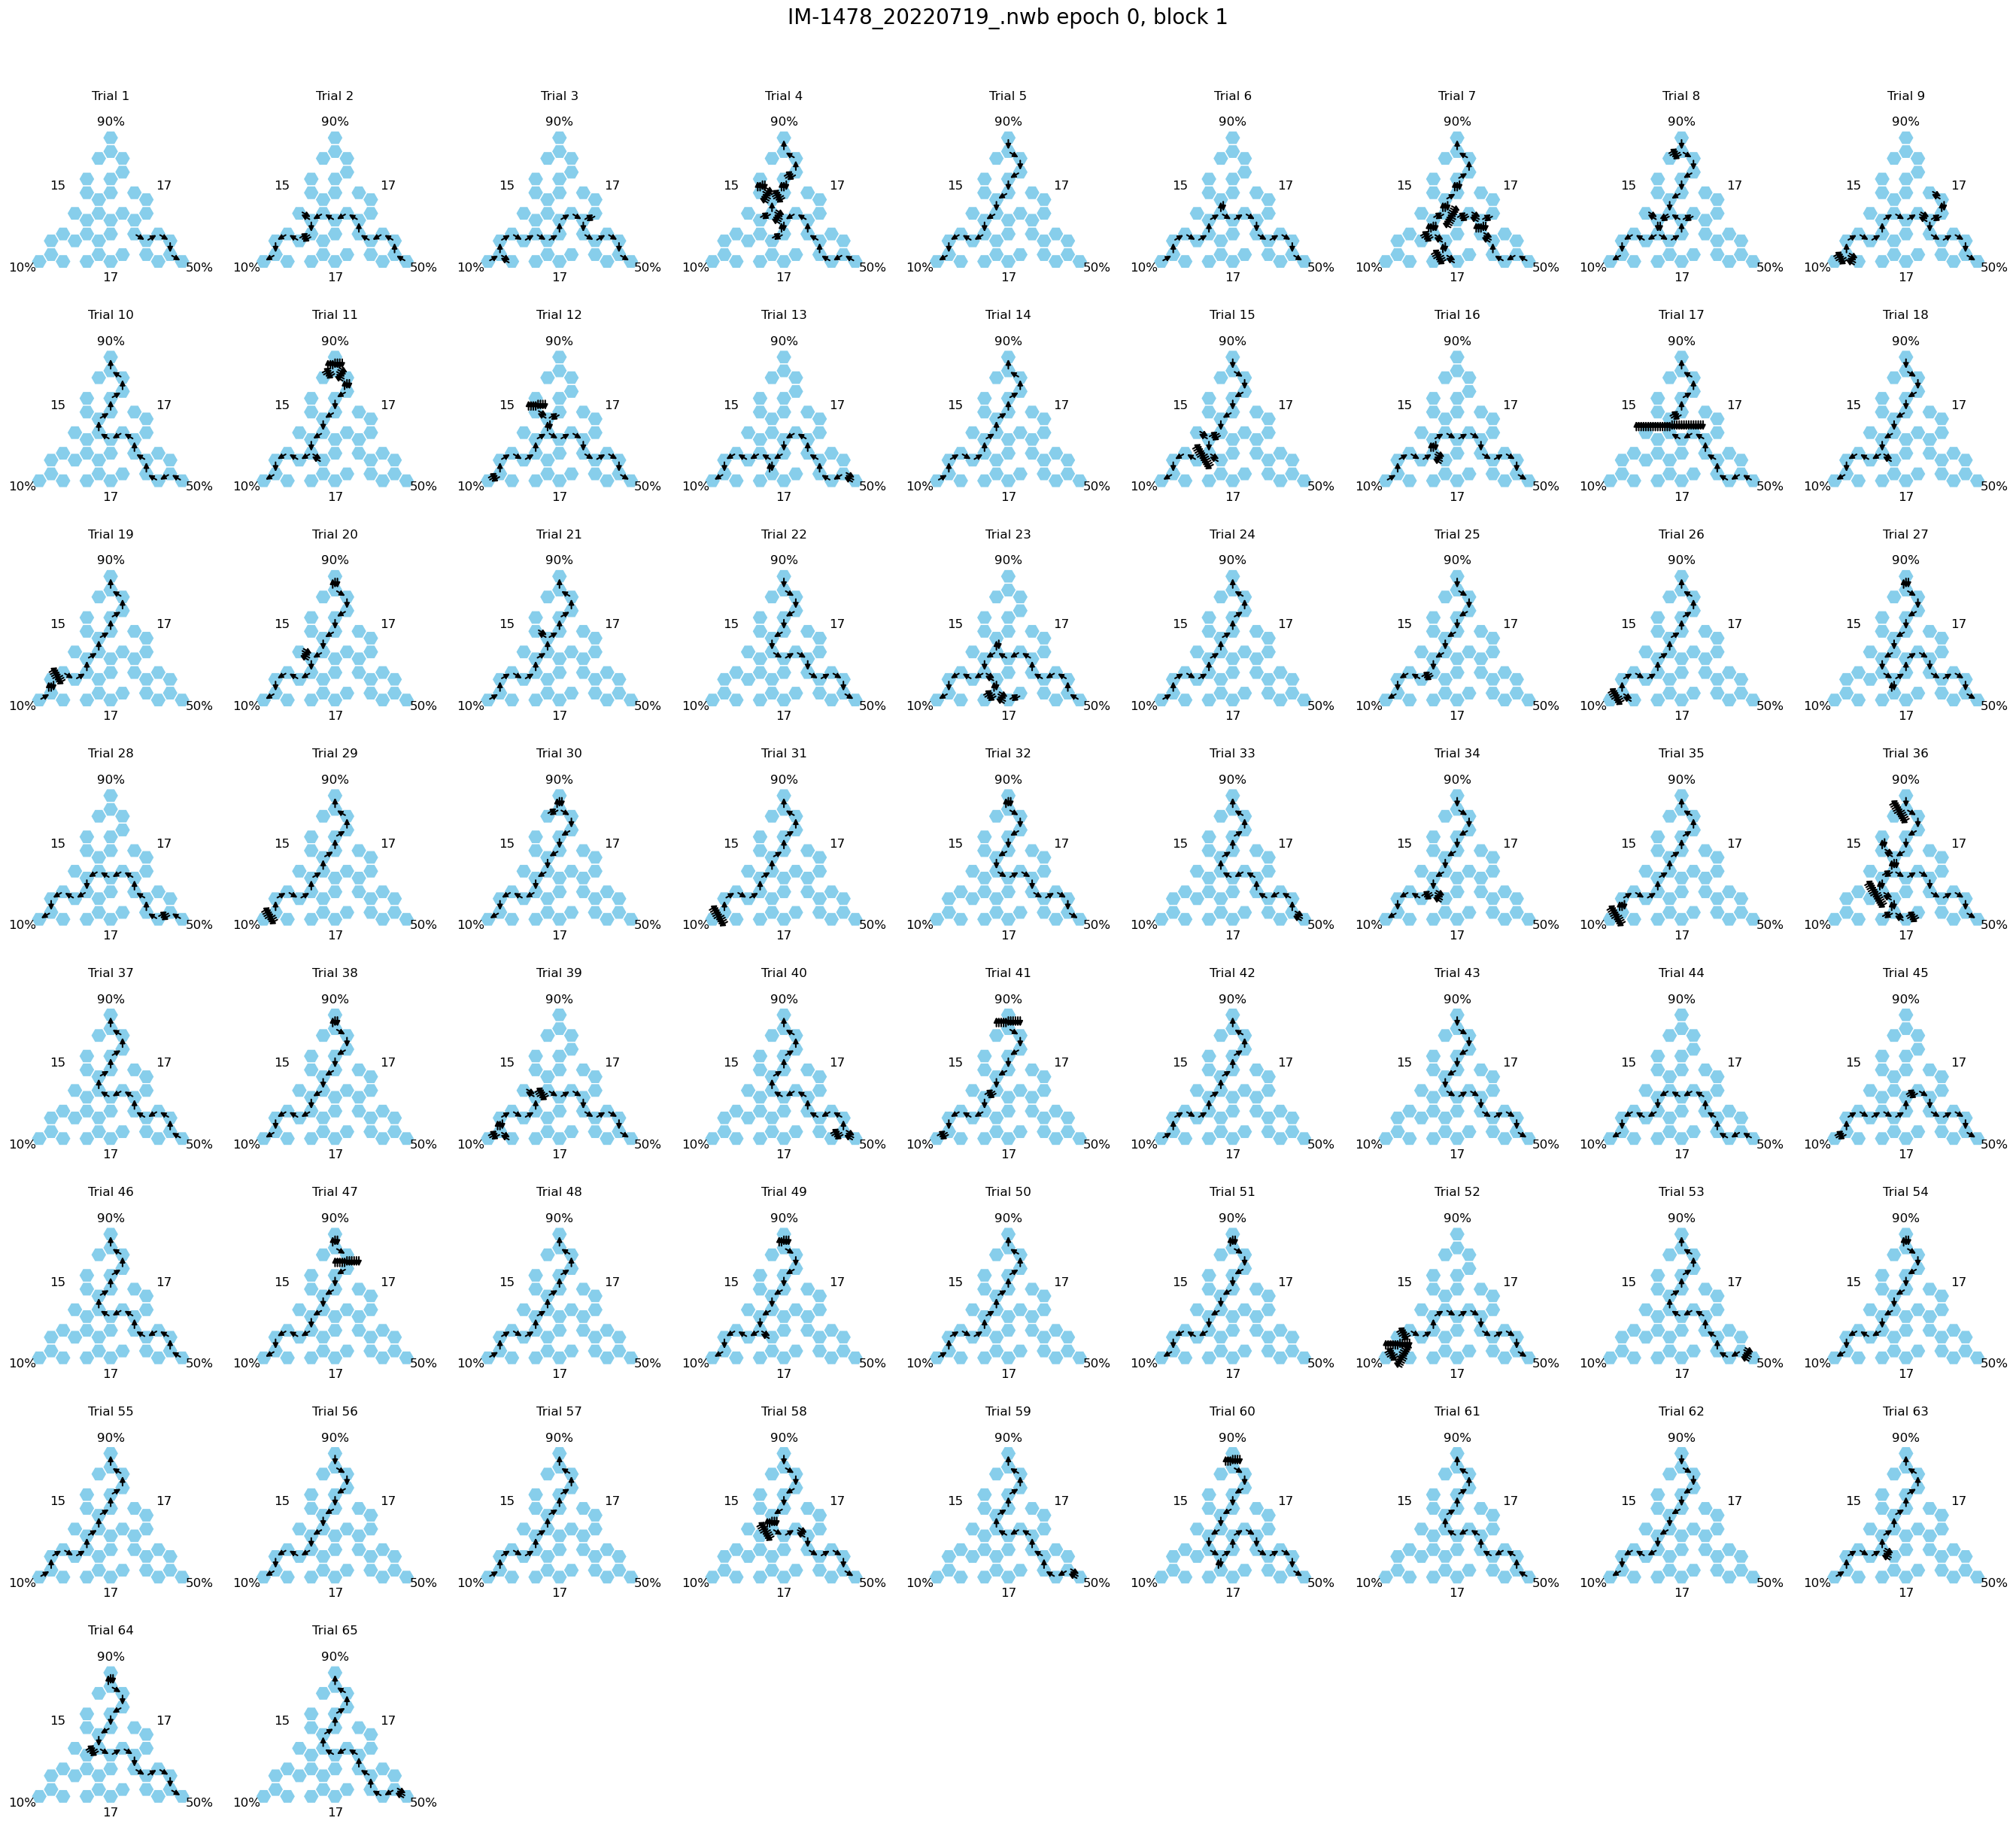

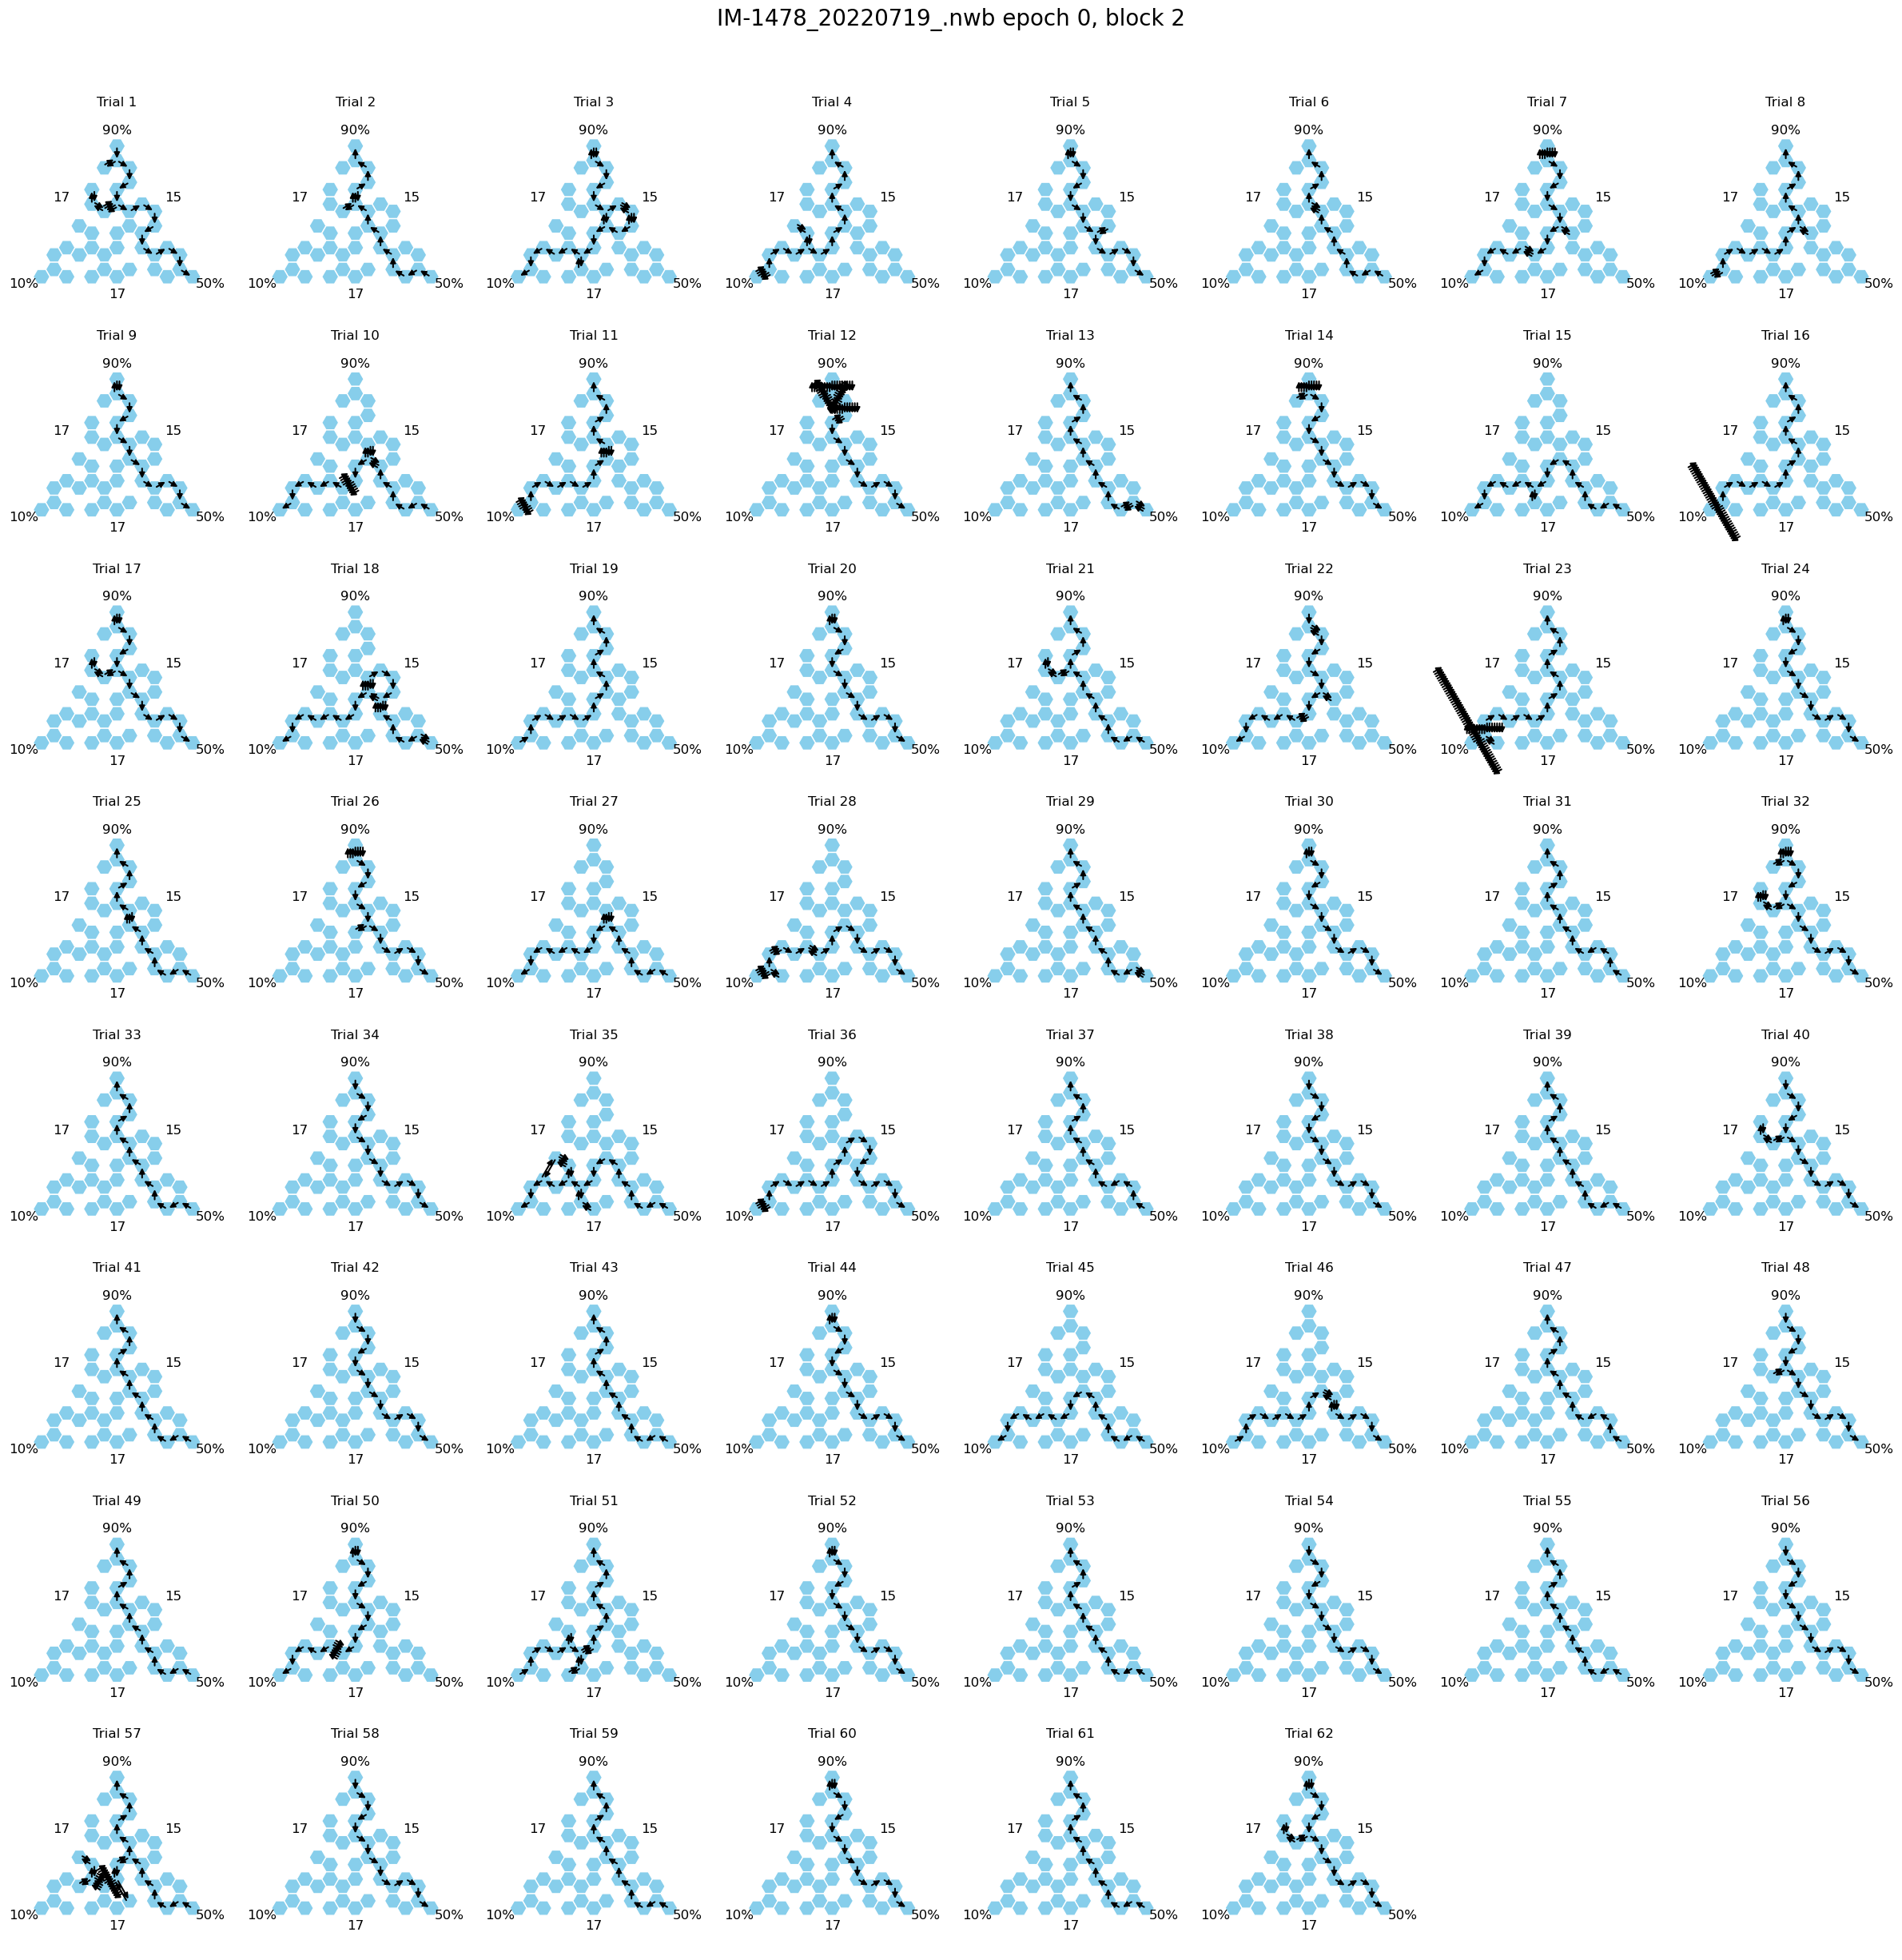

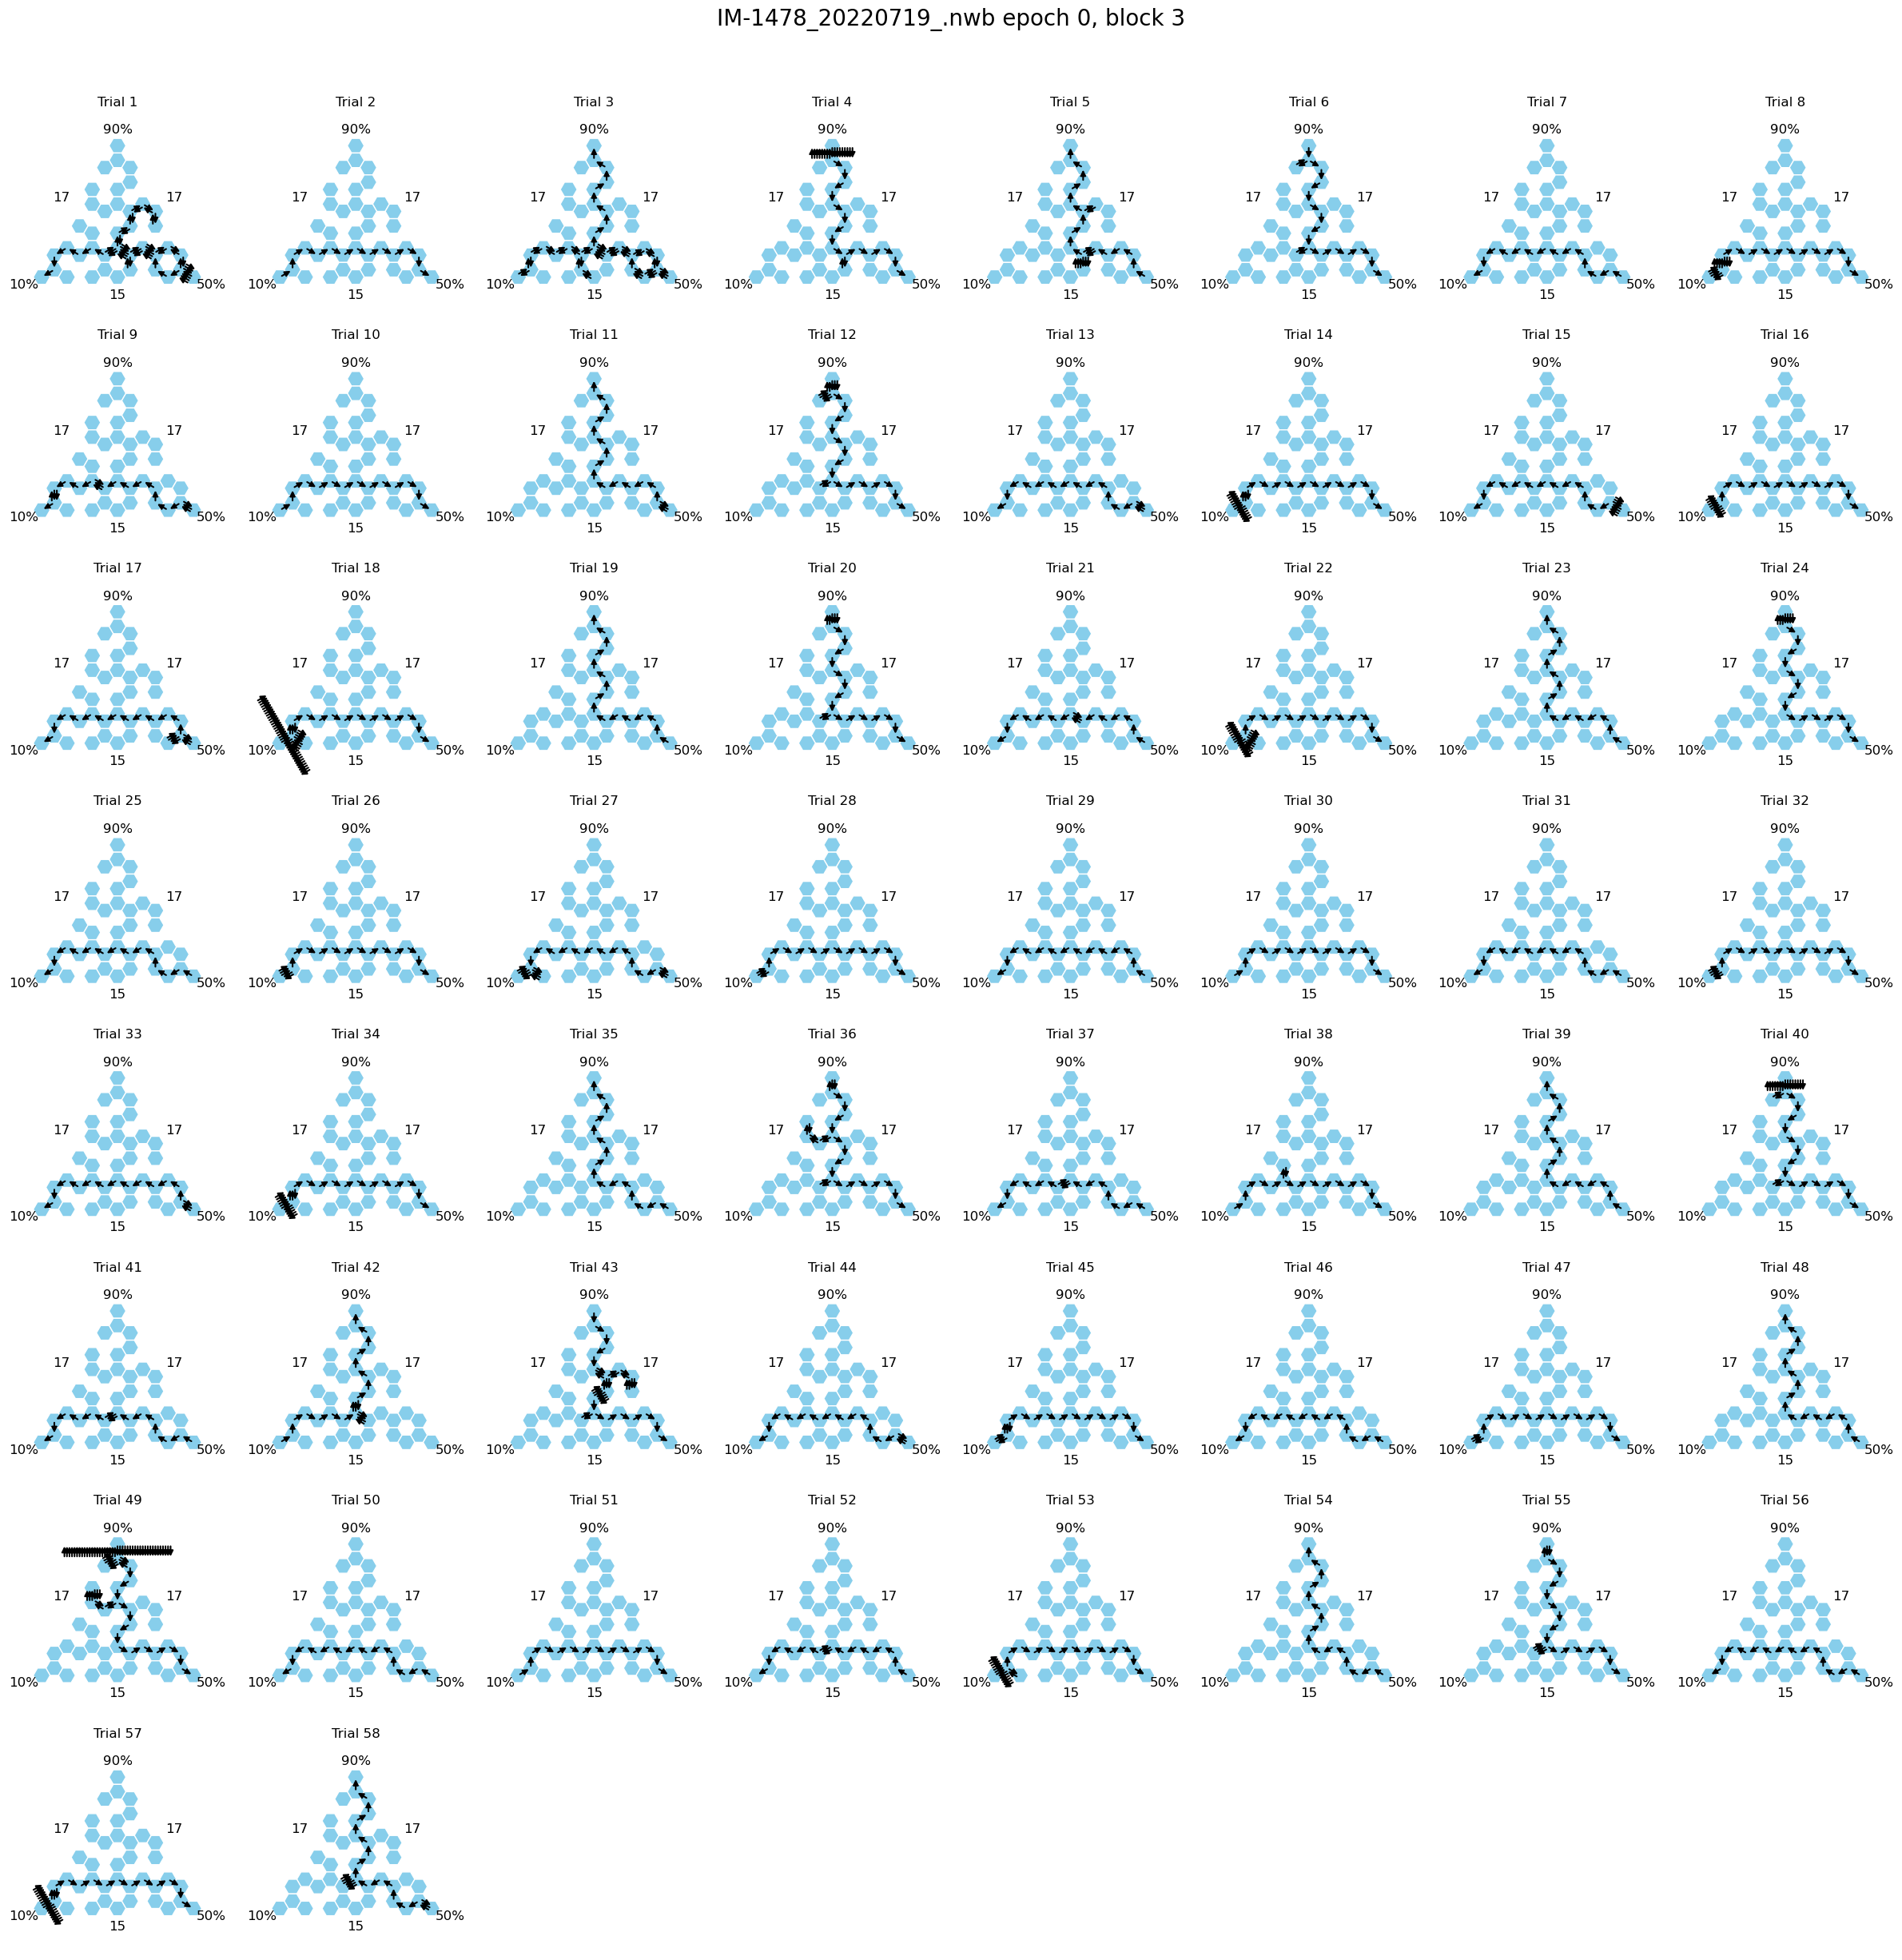

In [11]:
from spyglass_hexmaze.hex_maze_behavior import (
    HexPositionSelection,
    HexPosition,
    HexPath,
    HexMazeBlock,
)

## Step 4 check: Confirm the nwbfile has been added to the hex position tables
key = {"nwb_file_name": nwb_copy_file_name}

# Show the HexPositionSelection table
print("HexPositionSelection table:")
display(HexPositionSelection() & key)

# Show the HexPosition table
print("HexPosition table:")
display((HexPosition()) & key)

# Show the HexPath table
print("HexPath table:")
display(HexPath() & key)

# Plot hex paths for each block
hex_path_key = (HexPath() & key).fetch("KEY")[0]
blocks = (HexMazeBlock() & key).fetch("block")
for block in blocks:
    (HexPath() & hex_path_key).plot_block(block=block)

## 5. Populate photometry tables

In [24]:
## Step 5.
# Insert into all photometry-related tables
# (subject to change, sorry)
populate_all_fiber_photometry(nwb_copy_file_name)

[13:08:54][INFO] Spyglass: Populating photometry device tables from IM-1478_20220719_.nwb
INFO:spyglass:Populating photometry device tables from IM-1478_20220719_.nwb
[13:08:54][INFO] Spyglass: Inserted excitation sources ['Thorlabs Blue LED', 'Thorlabs Purple LED']
INFO:spyglass:Inserted excitation sources ['Thorlabs Blue LED', 'Thorlabs Purple LED']
[13:08:54][INFO] Spyglass: Inserted photodetectors ['Doric iFMC7-G2 (7 ports Fluorescence Mini Cube - Three Fluorophores)']
INFO:spyglass:Inserted photodetectors ['Doric iFMC7-G2 (7 ports Fluorescence Mini Cube - Three Fluorophores)']
[13:08:54][INFO] Spyglass: Inserted optical fibers ['Doric 0.66mm Flat 40mm Optic Fiber (left NAcc)', 'Doric 0.66mm Flat 40mm Optic Fiber (right NAcc)']
INFO:spyglass:Inserted optical fibers ['Doric 0.66mm Flat 40mm Optic Fiber (left NAcc)', 'Doric 0.66mm Flat 40mm Optic Fiber (right NAcc)']
[13:08:54][INFO] Spyglass: Inserted IndicatorInjection for AAVDJ-CAG-dLight1.3b at coords 1.7,-1.7,-6.2
INFO:spyglass:

#### Confirm it worked!

In [25]:
from spyglass_hexmaze.berke_fiber_photometry import (
    ExcitationSource,
    OpticalFiber,
    Photodetector,
    FiberPhotometrySeries,
    Indicator,
    IndicatorInjection,
)

## Step 5 check: Confirm the nwbfile has been added to the photometry tables
key = {"nwb_file_name": nwb_copy_file_name}

print("FiberPhotometrySeries table")
display(FiberPhotometrySeries() & key)

print("OpticalFiber table (not restricted by nwb_file_name, includes all sessions):")
display(OpticalFiber() & key)

print("Photodetector table (not restricted by nwb_file_name, includes all sessions):")
display(Photodetector() & key)

print(
    "ExcitationSource table (not restricted by nwb_file_name, includes all sessions):"
)
display(ExcitationSource() & key)

print("Indicator table (not restricted by nwb_file_name, includes all sessions):")
display(Indicator() & key)

print(
    "IndicatorInjection table (not restricted by nwb_file_name, includes all sessions):"
)
display(IndicatorInjection() & key)

FiberPhotometrySeries table


nwb_file_name name of the NWB file,photometry_series_name name of the FiberPhotometryResponseSeries in the nwbfile,interval_list_name descriptive name of this interval list,description,unit,series_object_id
IM-1478_20220719_.nwb,raw_green,raw_green valid times,"Raw green signal, 470nm",F,7c64cdf1-7016-4a6a-b9b1-7d43384d13d5
IM-1478_20220719_.nwb,raw_reference,raw_reference valid times,"Raw reference signal (isosbestic control), 405nm",F,35fe0939-cde4-4a6a-bb10-b71702984dc6
IM-1478_20220719_.nwb,z_scored_green_dFF,z_scored_green_dFF valid times,Z-scored green signal (470 nm) dF/F,dF/F,703d568d-8056-4d96-a01c-86b96486a8c5
IM-1478_20220719_.nwb,z_scored_reference_fitted,z_scored_reference_fitted valid times,Fitted Z-scored reference signal. This is the baseline for the dF/F calculation.,F,c3e777d4-fdf5-4ef6-85e1-777e865fc708


OpticalFiber table (not restricted by nwb_file_name, includes all sessions):


optical_fiber_name,manufacturer,model,numerical_aperture,core_diameter_in_um
Doric 0.66mm Flat 40mm Optic Fiber (left NAcc),Doric,MFC_200/250-0.66_40mm_MF2.5_FLT,0.66,200.0
Doric 0.66mm Flat 40mm Optic Fiber (right NAcc),Doric,MFC_200/250-0.66_40mm_MF2.5_FLT,0.66,200.0


Photodetector table (not restricted by nwb_file_name, includes all sessions):


...

excitation_source_name,manufacturer,model,illumination_type,excitation_wavelength_in_nm
Doric Blue LED,Doric,ilFMC7-G2,LED,470.0
Doric Green LED,Doric,ilFMC7-G2,LED,565.0
Doric Purple LED,Doric,ilFMC7-G2,LED,405.0
Thorlabs Blue LED,Thorlabs,M470F3,LED,470.0
Thorlabs Purple LED,Thorlabs,M405FP1,LED,405.0


Indicator table (not restricted by nwb_file_name, includes all sessions):


construct_name,name,description
AAV-DJ-CAG-dLight3.8,dLight3.8,AAV-DJ virus expressing the dopamine sensor dLight3.8 under the CAG promoter. Titer in vg/mL: 2e12. Volume in uL: 1.0.
AAV-hSyn-ACh3.8,gACh4h,"AAV virus expressing the acetylcholine sensor GRAB-ACh3.8 under the hSyn promoter. Unpublished, Yulong Li Lab . Titer in vg/mL: 1.15e13. Volume in uL: 1.0."
AAV9-hsyn-rDA3m,rDA3m,AAV9 virus expressing the red-shifted dopamine sensor GRAB rDA3m under the hSyn promoter. Titer in vg/mL: 5.89e12. Volume in uL: 1.0.
AAVDJ-CAG-dLight1.3b,dLight1.3b,AAV-DJ virus expressing the dopamine sensor dLight1.3b under the CAG promoter. Titer in vg/mL: 2e12. Volume in uL: 1.0.


IndicatorInjection table (not restricted by nwb_file_name, includes all sessions):


construct_name,"injection_coords Rounded coordinates string, e.g. '1.7,1.7,-6.0'",titer_in_vg_per_ml,volume_in_ul,injection_location,"injection_coords_in_mm [AP, ML, DV] in mm"
AAV-DJ-CAG-dLight3.8,"1.7,-1.7,-6.2",2e12,1,NAcc,=BLOB=
AAV-DJ-CAG-dLight3.8,"1.7,-1.7,-6.2",8e12,1,NAcc,=BLOB=
AAV-DJ-CAG-dLight3.8,"1.7,1.7,-6.2",2e12,1,NAcc,=BLOB=
AAV-DJ-CAG-dLight3.8,"1.7,1.7,-6.2",8e12,1,NAcc,=BLOB=
AAV-hSyn-ACh3.8,"1.8,-1.8,-6.2",1,1,NAcc,=BLOB=
AAV-hSyn-ACh3.8,"1.8,1.8,-6.2",1,1,NAcc,=BLOB=
AAV9-hsyn-rDA3m,"1.8,-1.8,-6.2",5,1,NAcc,=BLOB=
AAV9-hsyn-rDA3m,"1.8,1.8,-6.2",5,1,NAcc,=BLOB=
AAVDJ-CAG-dLight1.3b,"1.7,-1.7,-6.2",2e12,1,NAcc,=BLOB=
AAVDJ-CAG-dLight1.3b,"1.7,-1.7,-6.4",2e12,1,NAcc,=BLOB=


# Fast mode: All of the above, but in one cell!

---

In [ ]:
run = False

if run:
    import spyglass.common as sgc
    import spyglass.position as sgp
    import spyglass.data_import as sgi
    from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
    from spyglass_hexmaze.hex_maze_behavior import (
        populate_all_hexmaze,
        populate_hex_position,
    )
    from spyglass_hexmaze.berke_fiber_photometry import populate_all_fiber_photometry

    #nwb_file_name = "IM-1478_20220726.nwb"

    # When we run insert_session, spyglass creates a copy of the nwbfile named file name + _
    # We use nwb_copy_file_name to make it explicit which one to use.
    # Everything besides sgi.insert_session should use the copy file name
    nwb_copy_file_name = get_nwb_copy_filename(nwb_file_name)

    ## Step 1.
    # Insert session into spyglass (populates all common tables)
    sgi.insert_sessions(nwb_file_name)

    ## Step 2.
    # Once the session has been inserted, insert into basic hex maze tables
    # (populates HexMazeBlock, HexMazeBlock.Trial, HexMazeChoice, HexMazeTrialHistory, HexCentroids, HexMazeConfig tables)
    populate_all_hexmaze(nwb_copy_file_name)

    ## Step 3.
    # Process position using default parameters
    # We only have one epoch (epoch 0) for Berke lab, so "pos 0 valid times" is always the interval list name
    interval_list_name = "pos 0 valid times"

    # Our position selection key includes the nwbfile name, the interval to process, and the parameters to use
    position_selection_key = {
        "nwb_file_name": nwb_copy_file_name,
        "interval_list_name": interval_list_name,
        "trodes_pos_params_name": "berke_double_led",  # MAY WANT / NEED TO CHANGE THIS!!
    }
    # To associate a set of parameters with a given interval, insert them into the `TrodesPosSelection` table
    # Note "trodes position" really just means any imported unprocessed position
    sgp.v1.TrodesPosSelection.insert1(position_selection_key, skip_duplicates=True)

    # We can run the pipeline for our chosen interval/parameters by using the `TrodesPosV1.populate`
    # Each NWB file, interval, and parameter set is now associated with a new analysis file and object ID.
    sgp.v1.TrodesPosV1.populate(position_selection_key)

    ## Step 4.
    # Insert into HexPositionSelection, HexPosition, and HexPath tables
    # (must have run populate_all_hexmaze (Step 2) and have an entry in PositionOutput table (Step 3))
    populate_hex_position(nwb_copy_file_name)

    ## Step 5.
    # Insert into all photometry-related tables
    # (subject to change, sorry)
    populate_all_fiber_photometry(nwb_copy_file_name)

#### Confirm all tables are populated!!

wow, so many!

In [12]:
from spyglass_hexmaze.hex_maze_behavior import (
    HexMazeBlock,
    HexMazeChoice,
    HexMazeTrialHistory,
    HexCentroids,
    HexMazeConfig,
    HexPositionSelection,
    HexPosition,
    HexPath,
)
from spyglass_hexmaze.berke_fiber_photometry import (
    ExcitationSource,
    OpticalFiber,
    Photodetector,
    FiberPhotometrySeries,
    Indicator,
    IndicatorInjection,
)
from spyglass.common import IntervalList

key = {"nwb_file_name": nwb_copy_file_name}
# key = 'nwb_file_name LIKE "IM-%"'

print("------------------------- Hex maze tables! ------------------------- \n")

# Show the HexMazeBlock table
print("HexMazeBlock table:")
display(HexMazeBlock() & key)

# Show the Trial part table
print("HexMazeBlock().Trial part table:")
display(HexMazeBlock().Trial() & key)

# Show the HexMazeChoice table
print("HexMazeChoice table:")
display(HexMazeChoice() & key)

# Show the HexMazeTrialHistory table
print("HexMazeTrialHistory table:")
display(HexMazeTrialHistory() & key)

# Show the HexCentroids table (nwb_file_name is key)
print("HexCentroids table:")
display(HexCentroids() & key)

# Show the HexCentroids part table (nwb_file_name and hex)
print("HexCentroidsPart:")
display((HexCentroids().HexCentroidsPart()) & key)

# All config_ids for blocks in your session will also now exist in the HexMazeConfig table
# Show the HexMazeConfig table
print("HexMazeConfig table (not restricted by nwb_file_name, includes all sessions):")
display(HexMazeConfig())

# Show the HexPositionSelection table
print("HexPositionSelection table:")
display(HexPositionSelection() & key)

# Show the HexPosition table
print("HexPosition table:")
display((HexPosition()) & key)

# Show the HexPath table
print("HexPath table:")
display(HexPath() & key)

print("------------------------- Photometry tables! -------------------------\n")

print("FiberPhotometrySeries table")
display(FiberPhotometrySeries() & key)

print("OpticalFiber table (not restricted by nwb_file_name, includes all sessions):")
display(OpticalFiber() & key)

print("Photodetector table (not restricted by nwb_file_name, includes all sessions):")
display(Photodetector() & key)

print(
    "ExcitationSource table (not restricted by nwb_file_name, includes all sessions):"
)
display(ExcitationSource() & key)

print("Indicator table (not restricted by nwb_file_name, includes all sessions):")
display(Indicator() & key)

print(
    "IndicatorInjection table (not restricted by nwb_file_name, includes all sessions):"
)
display(IndicatorInjection() & key)

print(
    "------------------------- Interval Lists for this nwb! ------------------------- \n"
)

print("IntervalList table:")
display(IntervalList() & key)

------------------------- Hex maze tables! ------------------------- 

HexMazeBlock table:


nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),block the block number within the epoch,config_id maze configuration as a string,interval_list_name descriptive name of this interval list,p_a probability of reward at port A,p_b probability of reward at port B,p_c probability of reward at port C,num_trials number of trials in this block,task_type 'barrier shift' or 'probabilty shift'
IM-1478_20220719_.nwb,0,1,"8,9,16,18,23,27,35,42,44",epoch0_block1,90.0,10.0,50.0,65,barrier change
IM-1478_20220719_.nwb,0,2,"8,9,18,21,23,27,35,42,44",epoch0_block2,90.0,10.0,50.0,62,barrier change
IM-1478_20220719_.nwb,0,3,"8,9,18,21,23,24,27,42,44",epoch0_block3,90.0,10.0,50.0,58,barrier change


HexMazeBlock().Trial part table:


nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),block the block number within the epoch,block_trial_num trial number within the block,interval_list_name descriptive name of this interval list,epoch_trial_num trial number within the epoch,reward if the rat got a reward,"start_port A, B, or C","end_port A, B, or C","opto_cond description of opto condition, if any (delay / no_delay)","poke_interval np.array of [poke_in, poke_out]",duration trial duration in seconds
IM-1478_20220719_.nwb,0,1,1,epoch0_block1_trial1,1,0,None,C,None,=BLOB=,10.5167
IM-1478_20220719_.nwb,0,1,2,epoch0_block1_trial2,2,1,C,B,None,=BLOB=,31.1152
IM-1478_20220719_.nwb,0,1,3,epoch0_block1_trial3,3,1,B,C,None,=BLOB=,21.6368
IM-1478_20220719_.nwb,0,1,4,epoch0_block1_trial4,4,1,C,A,None,=BLOB=,54.662
IM-1478_20220719_.nwb,0,1,5,epoch0_block1_trial5,5,0,A,B,None,=BLOB=,9.01763
IM-1478_20220719_.nwb,0,1,6,epoch0_block1_trial6,6,0,B,C,None,=BLOB=,17.0026
IM-1478_20220719_.nwb,0,1,7,epoch0_block1_trial7,7,1,C,A,None,=BLOB=,81.1043
IM-1478_20220719_.nwb,0,1,8,epoch0_block1_trial8,8,0,A,B,None,=BLOB=,22.7089
IM-1478_20220719_.nwb,0,1,9,epoch0_block1_trial9,9,1,B,C,None,=BLOB=,32.461
IM-1478_20220719_.nwb,0,1,10,epoch0_block1_trial10,10,1,C,A,None,=BLOB=,18.5386


HexMazeChoice table:


...

construct_name,name,description
AAV-DJ-CAG-dLight3.8,dLight3.8,AAV-DJ virus expressing the dopamine sensor dLight3.8 under the CAG promoter. Titer in vg/mL: 2e12. Volume in uL: 1.0.
AAV-hSyn-ACh3.8,gACh4h,"AAV virus expressing the acetylcholine sensor GRAB-ACh3.8 under the hSyn promoter. Unpublished, Yulong Li Lab . Titer in vg/mL: 1.15e13. Volume in uL: 1.0."
AAV9-hsyn-rDA3m,rDA3m,AAV9 virus expressing the red-shifted dopamine sensor GRAB rDA3m under the hSyn promoter. Titer in vg/mL: 5.89e12. Volume in uL: 1.0.
AAVDJ-CAG-dLight1.3b,dLight1.3b,AAV-DJ virus expressing the dopamine sensor dLight1.3b under the CAG promoter. Titer in vg/mL: 2e12. Volume in uL: 1.0.


IndicatorInjection table (not restricted by nwb_file_name, includes all sessions):


construct_name,"injection_coords Rounded coordinates string, e.g. '1.7,1.7,-6.0'",titer_in_vg_per_ml,volume_in_ul,injection_location,"injection_coords_in_mm [AP, ML, DV] in mm"
AAV-DJ-CAG-dLight3.8,"1.7,-1.7,-6.2",2e12,1,NAcc,=BLOB=
AAV-DJ-CAG-dLight3.8,"1.7,-1.7,-6.2",8e12,1,NAcc,=BLOB=
AAV-DJ-CAG-dLight3.8,"1.7,-1.7,-6.4",4e12,1,NAcc,=BLOB=
AAV-DJ-CAG-dLight3.8,"1.7,1.7,-6.2",2e12,1,NAcc,=BLOB=
AAV-DJ-CAG-dLight3.8,"1.7,1.7,-6.2",8e12,1,NAcc,=BLOB=
AAV-DJ-CAG-dLight3.8,"1.7,1.7,-6.4",4e12,1,NAcc,=BLOB=
AAV-hSyn-ACh3.8,"1.8,-1.8,-6.2",1,1,NAcc,=BLOB=
AAV-hSyn-ACh3.8,"1.8,1.8,-6.2",1,1,NAcc,=BLOB=
AAV9-hsyn-rDA3m,"1.8,-1.8,-6.2",5,1,NAcc,=BLOB=
AAV9-hsyn-rDA3m,"1.8,1.8,-6.2",5,1,NAcc,=BLOB=


------------------------- Interval Lists for this nwb! ------------------------- 

IntervalList table:


nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list,valid_times numpy array with start/end times for each interval,"pipeline type of interval list (e.g. 'position', 'spikesorting_recording_v1')"
IM-1478_20220719_.nwb,00_r1,=BLOB=,
IM-1478_20220719_.nwb,00_r1 lfp band 1000Hz,=BLOB=,lfp band
IM-1478_20220719_.nwb,0383cc88-5ff0-46c4-a8e0-81ad3bbf4cbf,=BLOB=,spikesorting_recording_v1
IM-1478_20220719_.nwb,05e1f198-8c76-4afc-83d1-c644f3877753,=BLOB=,spikesorting_artifact_v1
IM-1478_20220719_.nwb,06717537-7455-4fca-9fbd-bb067529ea1e,=BLOB=,spikesorting_recording_v1
IM-1478_20220719_.nwb,09772a12-5642-4916-91f8-1fc8c5401fa5,=BLOB=,spikesorting_recording_v1
IM-1478_20220719_.nwb,10ae5230-f517-4c33-b450-28c48b60a980,=BLOB=,spikesorting_recording_v1
IM-1478_20220719_.nwb,13c29dc1-7e7a-40c1-bd8f-4b02a025a18a,=BLOB=,spikesorting_recording_v1
IM-1478_20220719_.nwb,14c914cc-2424-4bbe-b13c-2d12c7de605c,=BLOB=,spikesorting_recording_v1
IM-1478_20220719_.nwb,2ae98ab8-dd03-4b67-8dea-876b7690aa24,=BLOB=,spikesorting_artifact_v1
